In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
from clustergram import Clustergram
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [80]:
iris = load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [81]:
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [82]:
clusters = range(2, 11)

kmeans_scores = []
agg_scores = []

for cluster in clusters:
    km = KMeans(n_clusters=cluster, random_state=42, n_init=10)
    km_test = km.fit_predict(X_scaled)
    kmeans_scores.append(silhouette_score(X_scaled, km_test))

    agg = AgglomerativeClustering(n_clusters=cluster)
    agg_test = agg.fit_predict(X_scaled)
    agg_scores.append(silhouette_score(X_scaled, km_test))

K=2 fitted in 0.006 seconds.
K=3 fitted in 0.005 seconds.
K=4 fitted in 0.005 seconds.
K=5 fitted in 0.004 seconds.
K=6 fitted in 0.005 seconds.
K=7 fitted in 0.005 seconds.
K=8 fitted in 0.005 seconds.
K=9 fitted in 0.005 seconds.
K=10 fitted in 0.006 seconds.


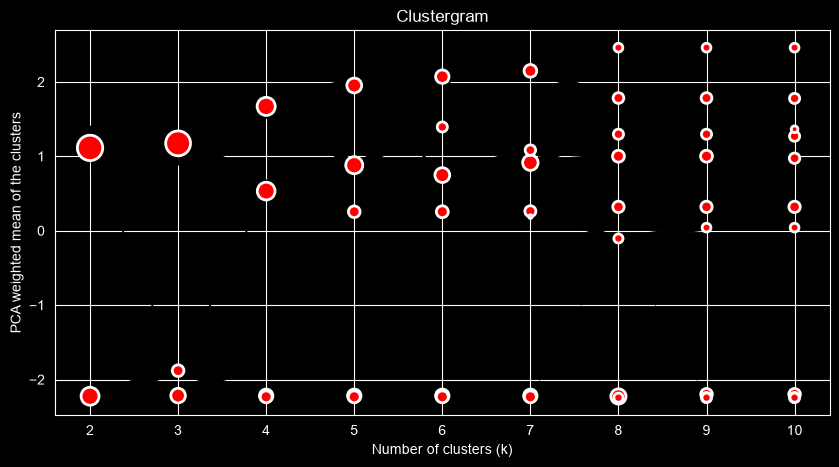

In [83]:
cgram = Clustergram(range(2, 11), method='kmeans', random_state=42)
cgram.fit(X_scaled)
cgram.plot(figsize=(10, 5))
plt.title('Clustergram')
plt.show()

# The best number of clusters is 2 and 3 because later they start to crash

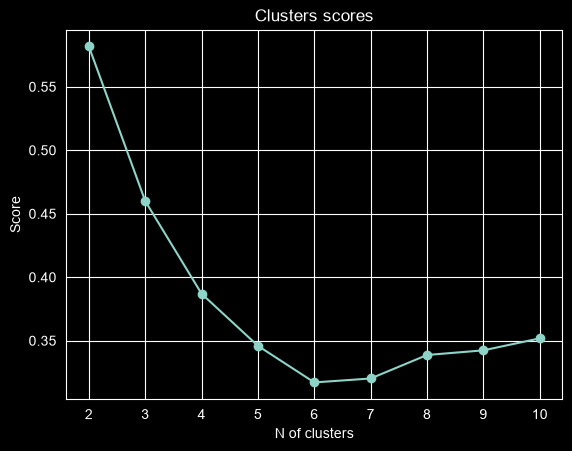

In [84]:
plt.xlabel('N of clusters')
plt.plot(clusters, kmeans_scores, marker='o', label='k-means')
plt.ylabel('Score')
plt.title('Clusters scores')
plt.show()

# The best n of clusters is 2 but 3 is also good

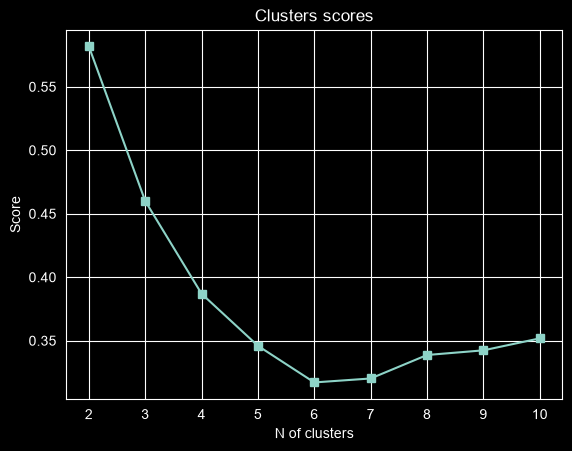

In [85]:
plt.xlabel('N of clusters')
plt.plot(clusters, agg_scores, marker='s', label='Agglomerative')
plt.ylabel('Score')
plt.title('Clusters scores')
plt.show()

# The best n of clusters is 2 but 3 is also good

In [86]:
dbscan = DBSCAN(eps = 0.6, min_samples = 5)
dbscan_test = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_test)) - (1 if -1 in dbscan_test else 0)

print('DBSCAN clusters -', n_clusters_db)
print('Score for DBSCAN -', silhouette_score(X_scaled, dbscan_test))

DBSCAN clusters - 2
Score for DBSCAN - 0.4027617471797909
